In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline

from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc, classification_report


import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data as a bunch
iris_data = load_iris()

target_names = iris_data.target_names # obtain the iris species names
feature_names = iris_data.feature_names

# load the data dirctly as dfs
df_X, df_y = load_iris(return_X_y=True,as_frame=True)

df_y_labels = df_y.to_frame (name="species_int_label")

df_y_names = pd.DataFrame(target_names[df_y_labels],columns=["species_name"])

df_test = []

In [23]:
model = KMeans ( n_clusters = 3 ) # instantiate the KMeans model as model

model. fit ( df_X ) # using the model instantiation, fit it to the data in “df”

labels = model. predict ( df_X ) # use the predict method of the model on the same samples to generate a label for each cluster to which it assessed to belong.

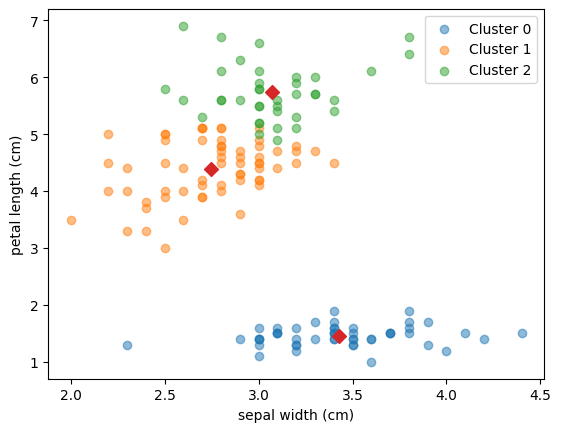

In [24]:
xs = df_X["sepal width (cm)"]
ys = df_X["petal length (cm)"]

for label in np.unique(labels):
    mask = labels == label
    plt.scatter(xs[mask], ys[mask], alpha=0.5, label=f"Cluster {label}")

plt.xlabel("sepal width (cm)")
plt.ylabel("petal length (cm)")
plt.legend()

# Assign the cluster centers: centroids
centroids = model.cluster_centers_

# Assign the columns of centroids: centroids_x, centroids_y
df_centroids = pd.DataFrame(centroids,index=target_names,columns=feature_names)

# Add Make a scatter plot of centroids_x and centroids_y
plt.scatter(df_centroids["sepal width (cm)"],df_centroids["petal length (cm)"],marker="D",s=50)

plt.show()


In [25]:
# turn the predicted labels into a df
df_labels = pd.DataFrame(labels,columns=["KMeans_label"])
df_com = pd.concat([df_X,df_y,df_y_names,df_labels], axis =1)

df_crosstab = pd.crosstab(df_com["KMeans_label"],df_com["species_name"])

print(df_crosstab)


species_name  setosa  versicolor  virginica
KMeans_label                               
0                 50           0          0
1                  0          48         14
2                  0           2         36
